# StatsBomb Data Exploration
Pull competitions, matches, events, and 360° freeze frames from StatsBomb open data.

In [1]:
from statsbombpy import sb
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

## 1. Available Competitions

In [2]:
competitions = sb.competitions()
print(f"Total competitions available: {len(competitions)}")
competitions[['competition_id', 'season_id', 'competition_name', 'country_name', 'season_name', 'competition_gender']]

Total competitions available: 75


/Users/adarshkasula/Documents/Applications/anaconda3/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_id,season_id,competition_name,country_name,season_name,competition_gender
0,9,281,1. Bundesliga,Germany,2023/2024,male
1,9,27,1. Bundesliga,Germany,2015/2016,male
2,1267,107,African Cup of Nations,Africa,2023,male
3,16,4,Champions League,Europe,2018/2019,male
4,16,1,Champions League,Europe,2017/2018,male
...,...,...,...,...,...,...
70,35,75,UEFA Europa League,Europe,1988/1989,male
71,53,315,UEFA Women's Euro,Europe,2025,female
72,53,106,UEFA Women's Euro,Europe,2022,female
73,72,107,Women's World Cup,International,2023,female


## 2. Matches — pick a competition

Change `COMPETITION_ID` and `SEASON_ID` to explore different datasets.

| Competition | competition_id | season_id |
|---|---|---|
| La Liga 2020/21 | 11 | 90 |
| FIFA World Cup 2022 | 43 | 106 |
| NWSL 2018 | 49 | 3 |
| Women's World Cup 2019 | 72 | 30 |

In [ ]:
COMPETITION_ID = 43   #Fifa World Cup 
SEASON_ID = 106      

matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
print(f"Matches found: {len(matches)}")
matches[['match_id', 'match_date', 'home_team', 'away_team', 'home_score', 'away_score', 'stadium', 'referee']].head(10)

Matches found: 64


,match_id,match_date,home_team,away_team,home_score,away_score,stadium,referee
0,3857256,2022-12-02,Serbia,Switzerland,2,3,Stadium 974,Fernando Andrés Rapallini
1,3869151,2022-12-03,Argentina,Australia,2,1,Ahmad bin Ali Stadium,Szymon Marciniak
2,3857257,2022-11-30,Australia,Denmark,1,0,Al Janoub Stadium,Mustapha Ghorbal
3,3857258,2022-11-24,Brazil,Serbia,2,0,Lusail Stadium,Alireza Faghani
4,3857288,2022-11-26,Tunisia,Australia,0,1,Al Janoub Stadium,Daniel Siebert
5,3857267,2022-11-29,Ecuador,Senegal,1,2,Sheikh Khalifa International Stadium,Clément Turpin
6,3869321,2022-12-09,Netherlands,Argentina,2,2,Lusail Stadium,Antonio Miguel Mateu Lahoz
7,3857287,2022-11-24,Uruguay,South Korea,0,0,Education City Stadium,Clément Turpin
8,3869486,2022-12-10,Morocco,Portugal,1,0,Al Thumama Stadium,Facundo Tello Figueroa
9,3869685,2022-12-18,Argentina,France,3,3,Lusail Stadium,Szymon Marciniak


## 3. Events for a single match

In [4]:
MATCH_ID = matches['match_id'].iloc[0]
print(f"Loading events for match_id: {MATCH_ID}")

events = sb.events(match_id=MATCH_ID)
print(f"Total events: {len(events)}")
print(f"Columns: {list(events.columns)}")
events.head(10)

Loading events for match_id: 3857256
Total events: 3211
Columns: ['bad_behaviour_card', 'ball_receipt_outcome', 'ball_recovery_recovery_failure', 'block_deflection', 'block_offensive', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_right_foot', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'injury_stoppage_in_chain', 'interception_outcome', 'location', 'match_id', 'minute', 'off_camera', 'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_deflected', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_length', 'pass_miscom

/Users/adarshkasula/Documents/Applications/anaconda3/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_type,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_open_goal,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,093f898d-33b1-4425-b591-37dd9c9bf70b,1,NaN,NaN,NaN,3857256,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Serbia,786,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 3412, 'lineup': [{'player': {'id': 20600, ...",Serbia,786,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79a9efbb-b5e5-45b0-983d-8729bcc4a0e1,2,NaN,NaN,NaN,3857256,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Serbia,786,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id': 17974, ...",Switzerland,773,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c4cdfc71-b9f4-4751-a714-e816c1419457,3,NaN,NaN,NaN,3857256,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Serbia,786,[51f295b8-da96-428e-ab47-90f380f8cf53],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Switzerland,773,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51f295b8-da96-428e-ab47-90f380f8cf53,4,NaN,NaN,NaN,3857256,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Serbia,786,[c4cdfc71-b9f4-4751-a714-e816c1419457],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Serbia,786,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,749a27ed-92e8-4723-9ac5-dcd074535537,1516,NaN,NaN,NaN,3857256,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,NaN,NaN,NaN,107,Switzerland,773,[f6a97503-ed87-4a13-89ba-8c4bbccc6686],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Serbia,786,00:00:00.000,Half Start,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f6a97503-ed87-4a13-89ba-8c4bbccc6686,1517,NaN,NaN,NaN,3857256,45,NaN,NaN,NaN,NaN,NaN,NaN,Na

## 4. Event type breakdown

In [5]:
# Extract type name from the nested dict
events['type_name'] = events['type'].apply(lambda t: t['name'] if isinstance(t, dict) else t)
events['type_name'].value_counts()

type_name
Pass                 966
Ball Receipt*        907
Carry                667
Pressure             177
Ball Recovery         92
Duel                  68
Block                 40
Clearance             36
Foul Committed        35
Foul Won              34
Goal Keeper           30
Shot                  26
Miscontrol            25
Interception          23
Dispossessed          23
Dribble               12
Injury Stoppage       10
Substitution           9
Dribbled Past          6
Referee Ball-Drop      4
Half Start             4
Half End               4
Bad Behaviour          4
Tactical Shift         2
Starting XI            2
Error                  2
Player Off             1
Player On              1
Shield                 1
Name: count, dtype: int64

## 5. Ball locations (passes + carries)

In [6]:
pass_carry = events[events['type_name'].isin(['Pass', 'Carry'])].copy()
pass_carry['ball_x'] = pass_carry['location'].apply(lambda l: l[0] if isinstance(l, list) else None)
pass_carry['ball_y'] = pass_carry['location'].apply(lambda l: l[1] if isinstance(l, list) else None)

pass_carry[['index', 'type_name', 'ball_x', 'ball_y', 'possession', 'team', 'player']].head(20)

,index,type_name,ball_x,ball_y,possession,team,player
6,5,Pass,61.0,40.1,2,Switzerland,Breel-Donald Embolo
7,8,Pass,39.7,45.5,2,Switzerland,Remo Freuler
8,11,Pass,42.3,72.2,2,Switzerland,Silvan Widmer
9,13,Pass,23.1,62.4,2,Switzerland,Fabian Lukas Schär
10,16,Pass,105.6,74.4,2,Switzerland,Djibril Sow
11,23,Pass,105.6,47.5,2,Switzerland,Xherdan Shaqiri
12,31,Pass,77.7,35.9,2,Switzerland,Manuel Obafemi Akanji
13,33,Pass,20.0,80.0,3,Serbia,Andrija Živković
14,35,Pass,22.8,71.9,3,Serbia,Saša Lukić
15,41,Pass,113.6,12.4,4,Switzerland,Djibril Sow


In [7]:
shots = events[events['type_name'] == 'Shot'].copy()

# statsbombpy flattens nested dicts into prefixed columns (shot_outcome, shot_statsbomb_xg, etc.)
# Extract outcome name — stored as a dict or already a string depending on version
if 'shot_outcome' in shots.columns:
    shots['shot_outcome'] = shots['shot_outcome'].apply(
        lambda s: s.get('name', '') if isinstance(s, dict) else str(s) if pd.notna(s) else ''
    )
else:
    shots['shot_outcome'] = ''

if 'shot_statsbomb_xg' in shots.columns:
    shots['xg'] = shots['shot_statsbomb_xg']
else:
    shots['xg'] = None

shots['ball_x'] = shots['location'].apply(lambda l: l[0] if isinstance(l, list) else None)
shots['ball_y'] = shots['location'].apply(lambda l: l[1] if isinstance(l, list) else None)

print(f"Total shots: {len(shots)}")
shots[['player', 'team', 'ball_x', 'ball_y', 'xg', 'shot_outcome']].sort_values('xg', ascending=False)

Total shots: 26


,player,team,ball_x,ball_y,xg,shot_outcome
2688,Breel-Donald Embolo,Switzerland,114.4,36.9,0.726976,Goal
2692,Breel-Donald Embolo,Switzerland,116.1,39.3,0.664771,Off T
2679,Dušan Vlahović,Serbia,115.4,38.6,0.516879,Saved
2685,Xherdan Shaqiri,Switzerland,107.7,49.2,0.393468,Off T
2675,Breel-Donald Embolo,Switzerland,113.1,40.7,0.353289,Saved
2697,Christian Fassnacht,Switzerland,105.3,28.9,0.316817,Saved
2686,Dušan Vlahović,Serbia,106.2,31.8,0.159284,Goal
2690,Remo Freuler,Switzerland,107.2,41.2,0.153815,Goal
2680,Remo Freuler,Switzerland,107.8,35.9,0.096118,Blocked
2683,Dušan Vlahović,Serbia,109.6,35.4,0.086285,Saved


## 7. 360° Freeze Frames

In [8]:
# NOTE: 360° freeze frames only exist for select competitions.
# Competitions with 360 data: FIFA World Cup 2022 (43/106), UEFA Euro 2020 (55/43),
# Women's World Cup 2023 (72/107), UEFA Women's Euro 2022 (53/106)
#
# La Liga (competition_id=11) does NOT have 360 data.
# Switch to a supported competition to see freeze frames.

MATCH_ID_360 = matches['match_id'].iloc[0]  # update if using a different competition

try:
    frames = sb.frames(match_id=MATCH_ID_360)
except Exception as e:
    print(f"Error fetching frames: {e}")
    frames = None

if frames is not None and not frames.empty:
    print(f"Freeze frame rows: {len(frames)}")
    print(f"Columns: {list(frames.columns)}")

    # location may already be exploded into x/y in newer statsbombpy versions
    if 'location' in frames.columns:
        frames['x'] = frames['location'].apply(lambda l: l[0] if isinstance(l, list) else None)
        frames['y'] = frames['location'].apply(lambda l: l[1] if isinstance(l, list) else None)
        frames = frames.drop(columns=['location'])

    display(frames.head(20))
else:
    print("No 360 freeze frames for this match.")
    print("To get freeze frames, use FIFA World Cup 2022:")
    print("  competition_id = 43, season_id = 106")
    print("Then update MATCH_ID_360 with a match_id from that competition.")

/Users/adarshkasula/Documents/Applications/anaconda3/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Freeze frame rows: 41562
Columns: ['id', 'visible_area', 'match_id', 'teammate', 'actor', 'keeper', 'location']


,id,visible_area,match_id,teammate,actor,keeper,x,y
0,4acb4fd2-f46a-4d73-993c-e06597873924,"[18.8151432741548, 80.0, 44.7117185559985, 0.0, 77.19252...",3857256,True,False,False,31.885449,47.289130
1,4acb4fd2-f46a-4d73-993c-e06597873924,"[18.8151432741548, 80.0, 44.7117185559985, 0.0, 77.19252...",3857256,True,False,False,40.762566,14.657225
2,4acb4fd2-f46a-4d73-993c-e06597873924,"[18.8151432741548, 80.0, 44.7117185559985, 0.0, 77.19252...",3857256,True,False,False,45.765232,69.890950
3,4acb4fd2-f46a-4d73-993c-e06597873924,"[18.8151432741548, 80.0, 44.7117185559985, 0.0, 77.19252...",3857256,True,False,False,45.923999,41.324219
4,4acb4fd2-f46a-4d73-993c-e06597873924,"[18.8151432741548, 80.0, 44.7117185559985, 0.0, 77.19252...",3857256,True,False,False,53.649592,31.368630
5,4acb4fd2-f46a-4d73-993c-e06597873924,"[18.8151432741548, 80.0, 44.7117185559985, 0.0, 77.19252...",3857256,True,False,False,57.221077,69.484720
6,4acb4fd2-f46a-4d73-993c-e06597873924,"[18.8151432741548, 80.0, 44.7117185559985, 0.0, 77.19252...",3857256,True,False,False,58.963536,49.056717
7,4acb4fd2-f46a-4d73-993c-e06597873924,"[18.8151432741548, 80.0, 44.7117185559985, 0.0, 77.19252...",3857256,True,False,False,60.159949,7.849366
8,4acb4fd2-f46a-4d73-993c-e06597873924,"[18.8151432741548, 80.0, 44.7117185559985, 0.0, 77.19252...",3857256,False,False,False,60.952056,27.553933
9,4acb4fd2-f46a-4d73-993c-e06597873924,"[18.8151432741548, 80.0, 44.7117185559985, 0.0, 77.19252...",3857256,True,True,False,61.000000,40.099998


## 8. Single freeze frame — player positions for one shot

In [9]:
if frames is not None and not frames.empty and len(shots) > 0:
    top_shot_id = shots.sort_values('xg', ascending=False).iloc[0]['id']
    shot_frame = frames[frames['id'] == top_shot_id]
    print(f"Players in freeze frame for highest-xG shot (event {top_shot_id}):")
    print(shot_frame[['teammate', 'actor', 'keeper', 'x', 'y']])
else:
    print("No freeze frames available for this match.")

Players in freeze frame for highest-xG shot (event 663eefd5-97eb-4c07-9ac7-241b3bfe1356):
       teammate  actor  keeper           x          y
18229     False  False   False  105.437842  42.299876
18230     False  False   False  106.020559  47.005647
18231     False  False   False  108.092337  47.014120
18232      True  False   False  108.290821  40.124425
18233      True  False   False  110.055716  54.930807
18234     False  False   False  111.027898  36.068922
18235     False  False   False  111.323466  40.128772
18236      True  False   False  111.817750  32.833976
18237     False  False   False  112.396245  43.819678
18238      True  False   False  112.992966  47.210729
18239     False  False   False  113.122474  50.855373
18240      True   True   False  114.400002  36.900002
18241     False  False    True  116.961773  41.512195


## 9. Quick pitch plot — shot locations

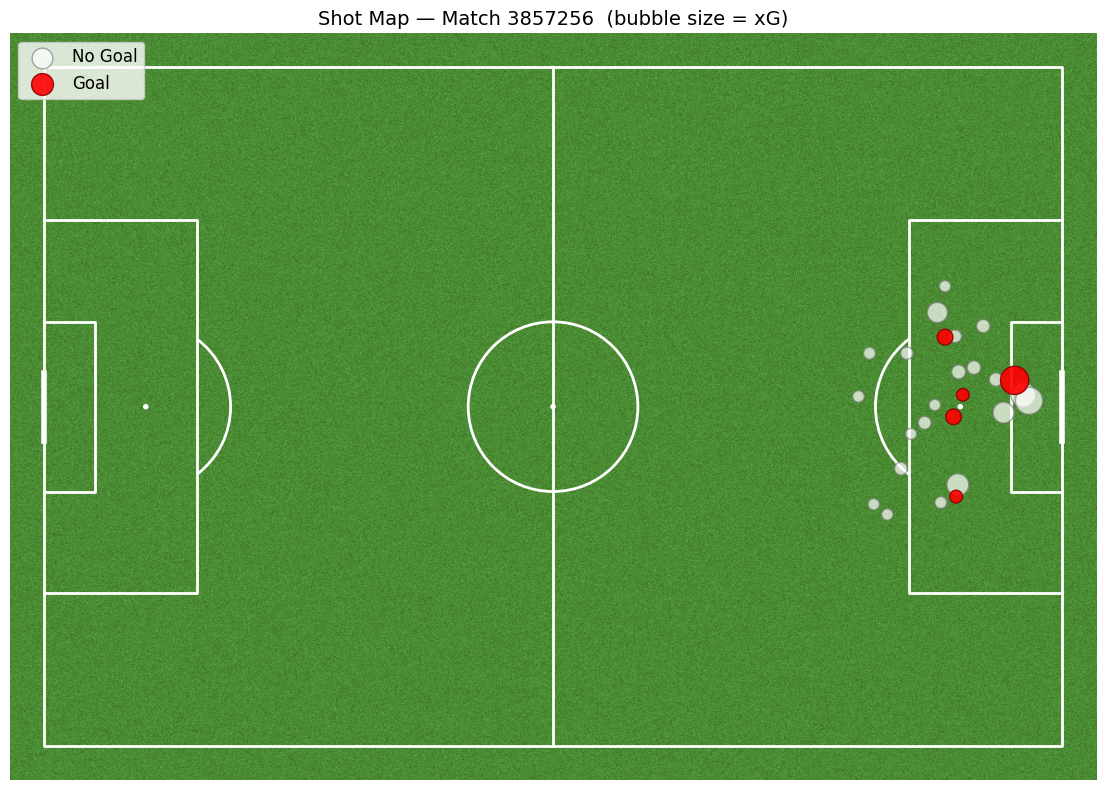

In [10]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))

goals = shots[shots['shot_outcome'] == 'Goal']
non_goals = shots[shots['shot_outcome'] != 'Goal']

pitch.scatter(non_goals['ball_x'], non_goals['ball_y'], ax=ax,
              s=non_goals['xg'] * 500 + 50, color='white', edgecolors='grey',
              alpha=0.7, label='No Goal')
pitch.scatter(goals['ball_x'], goals['ball_y'], ax=ax,
              s=goals['xg'] * 500 + 50, color='red', edgecolors='darkred',
              alpha=0.9, label='Goal')

ax.legend(loc='upper left', fontsize=12)
ax.set_title(f'Shot Map — Match {MATCH_ID}  (bubble size = xG)', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Save raw data to parquet

In [11]:
from pathlib import Path

raw_dir = Path('../data/raw')
raw_dir.mkdir(parents=True, exist_ok=True)

events.to_parquet(raw_dir / f'events_{MATCH_ID}.parquet', index=False)
print(f"Saved events_{MATCH_ID}.parquet")

if frames is not None and not frames.empty:
    frames.to_parquet(raw_dir / f'frames_{MATCH_ID}.parquet', index=False)
    print(f"Saved frames_{MATCH_ID}.parquet")

print("Done. Files in data/raw/:")
for f in sorted(raw_dir.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

Saved events_3857256.parquet
Saved frames_3857256.parquet
Done. Files in data/raw/:
  .gitkeep  (0.0 KB)
  events_3857256.parquet  (407.6 KB)
  frames_3857256.parquet  (862.6 KB)
